In [3]:
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib
import plotly.express as px
%matplotlib inline 

In [4]:
######################
#1. LOADDING PATH VARIABLE
######################
load_dotenv()
data_path = os.getenv("DATA_PATH")

In [5]:
######################
#2. LOADDING DATASET 
######################
df = pd.read_csv(data_path)

In [6]:
print(df.isnull().sum()) # Checking for any missing values
print(df.head())    


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
######################
#3. EDA  i.e finding relations between charges and other columns , also individual columns
######################

df.age.describe()

fig = px.histogram(
    df,
    x = "age",
    marginal = "box",
    nbins = 47,
    title = "Distribution of Age"
    )
fig.update_layout(bargap=0.1)
fig.show()

In [11]:
fig = px.histogram(
    df,
    x = "bmi",
    marginal = "box",
    title = "Distribution of BMI (Body Mass Index)",
    color_discrete_sequence = ['red']
)
fig.update_layout(bargap = 0.1)
fig.show()

In [12]:
fig = px.histogram(
    df,
    x = "charges",
    marginal = "box",
    color = "smoker",
    color_discrete_sequence = ["green","grey"],
    title = "Annual Medical Charges "
)
fig.update_layout(bargap=0.1)
fig.show()

In [13]:
fig = px.histogram(
    df,
    x = "charges",
    marginal = "box",
    color = "sex",
    color_discrete_sequence = ["yellow","red"],
    title = "Annual Medical Charges"
)
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [15]:
fig = px.histogram(df,x="smoker",color="sex",title="Smoker")
fig.show()

In [16]:
fig = px.scatter(df,
                 x="age",
                 y="charges",
                 title="Age v/s Charges",
                 opacity=0.8,
                 color="smoker",
                 hover_data=["sex"])
fig.update_traces(marker_size=5)
fig.show()

In [17]:
fig = px.scatter(df,
                 x="bmi",
                 y="charges",
                 title="Bmi v/s Charges",
                 opacity=0.8,
                 color="smoker",
                 hover_data=["sex"])
fig.update_traces(marker_size=5)
fig.show()

In [18]:
fig = px.violin(df,
                 x="children",
                 y="charges",
                 title="Children v/s Charges",
                 )
fig.update_traces(marker_size=5)
fig.show()

In [19]:
######################
#4. Looking for Co-relations
######################

In [20]:
print(df.charges.corr(df.age))

0.2990081933306476


In [21]:
print(df.charges.corr(df.bmi))

0.19834096883362878


In [22]:
print(df.charges.corr(df.children))

0.06799822684790469


In [23]:
df.smoker

0       yes
1        no
2        no
3        no
4        no
       ... 
1333     no
1334     no
1335     no
1336     no
1337    yes
Name: smoker, Length: 1338, dtype: object

In [24]:
smoker_values = {"no":0,"yes":1}
smoker_numeric = df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [25]:
print(df.charges.corr(smoker_numeric))

0.7872514304984782


In [26]:
# pandas has a .corr() method which gives us correlation of all pairs of numeric columns
new_df = pd.DataFrame(df,columns=["age","bmi","children","charges"])
new_df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


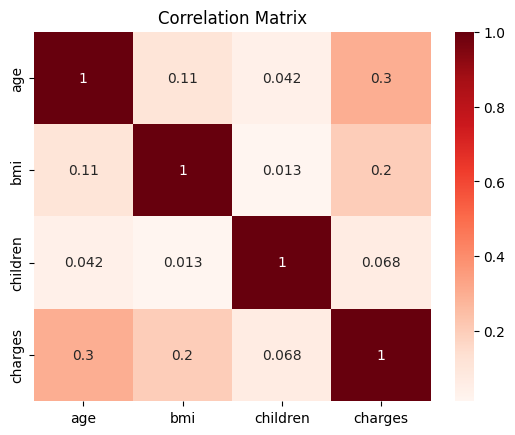

In [27]:
sns.heatmap(new_df.corr(),cmap="Reds",annot=True)
plt.title("Correlation Matrix");

Non Smokers

In [28]:
non_smoker_df = df[df["smoker"] == "no"]
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


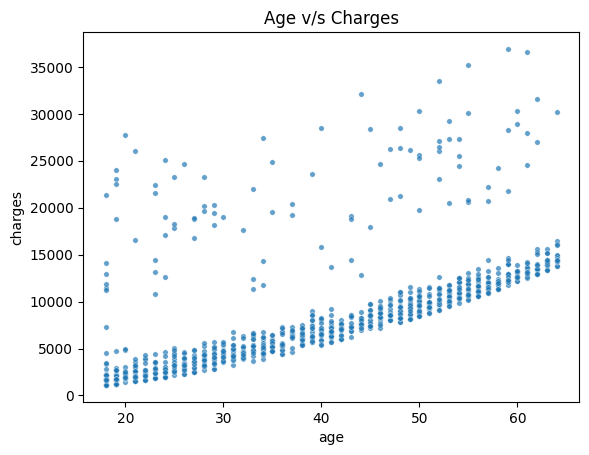

In [29]:
plt.title("Age v/s Charges")
sns.scatterplot(data=non_smoker_df,x="age",y="charges",alpha=0.7,s=15);

In [30]:
def estimate_charges(age,w,b):
    return w * age + b

In [31]:
w = 50
b = 100
estimate_charges(30,w,b)

1600

In [32]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages,w,b)

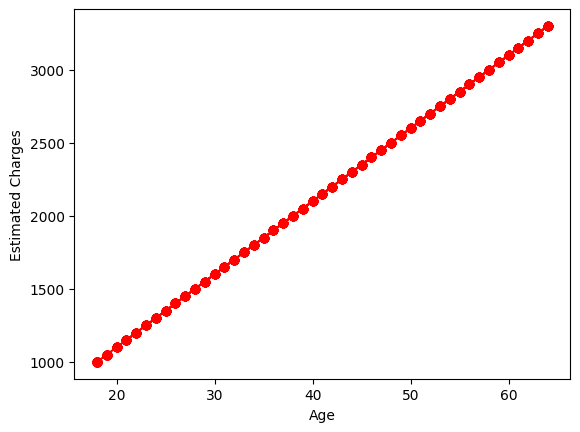

In [33]:
plt.plot(ages,estimated_charges,'r-o');
plt.xlabel("Age");
plt.ylabel("Estimated Charges");


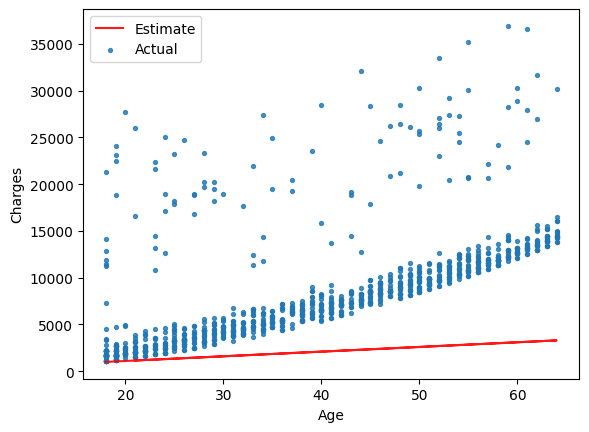

In [34]:
target = non_smoker_df.charges;
plt.plot(ages,estimated_charges,'r',alpha=0.9);
plt.scatter(ages,target,s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges');
plt.legend(['Estimate','Actual']);

In [35]:
def try_parametes(w,b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages,w,b)

    plt.plot(ages,estimated_charges,'r',alpha=0.9);
    plt.scatter(ages,target,s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges');
    plt.legend(['Estimate','Actual']);

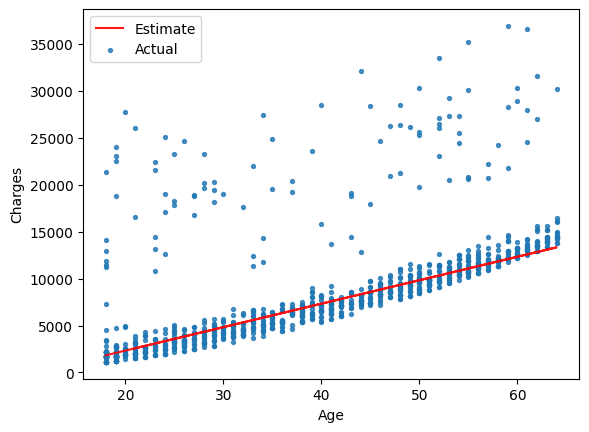

In [36]:
try_parametes(250,-2675)

In [37]:
def rmse(targets,predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [38]:
w = 275
b = -2815

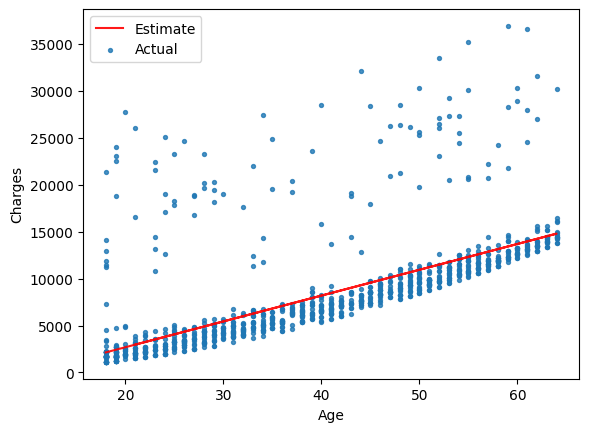

In [39]:
try_parametes(w,b)

In [40]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age,w,b)

In [41]:
print(rmse(targets,predicted))

4682.503626377362


In [42]:
model = LinearRegression()

In [43]:
inputs = non_smoker_df[['age']]  #needs to be 2-D array 
targets = non_smoker_df.charges  # not necessary 2-D
print("Target shape:",targets.shape)
print("Input shape:",inputs.shape)

Target shape: (1064,)
Input shape: (1064, 1)


In [44]:
model.fit(inputs,targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
model.predict([[23],[37],[61]])

In [46]:
predictions = model.predict(inputs)
print(predictions)

[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


In [47]:
print(rmse(targets,predictions))

4662.505766636395


In [48]:
model.coef_

array([267.24891283])

In [49]:
model.intercept_

np.float64(-2091.4205565650864)

In [50]:
# Above we created a model for non-smokers now lets create a model for smokers here

In [51]:
# Multiple features  - 2
inputs , targets = non_smoker_df[["age","bmi",]] , non_smoker_df.charges

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)

print("Loss: ",loss)

Loss:  4662.3128354612945


In [52]:
fig = px.strip(non_smoker_df,x="children",y="charges",title="Children vs Charges")
fig.update_traces(marker_size = 4 , marker_opacity = 0.7)
fig.show()

In [53]:
# Multiple features  - 3
inputs , targets = non_smoker_df[["age","bmi","children"]] , non_smoker_df.charges

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)

print("Loss: ",loss)

Loss:  4608.470405038247


In [54]:
# Multiple features  - 3 on full dataset
inputs , targets = df[["age","bmi","children"]] , df.charges

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)

print("Loss: ",loss)

Loss:  11355.317901125973


Using Categorical Values

In [55]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [56]:
smoker_codes = {"yes":1,"no":0}
df["smoker_codes"] = df.smoker.map(smoker_codes)

In [57]:
print(df.charges.corr(df.smoker_codes))


0.7872514304984782


In [58]:
inputs, targets = df[["age","bmi","children","smoker_codes"]],df["charges"]

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)
print("Loss : " ,loss)

Loss :  6056.439217188081


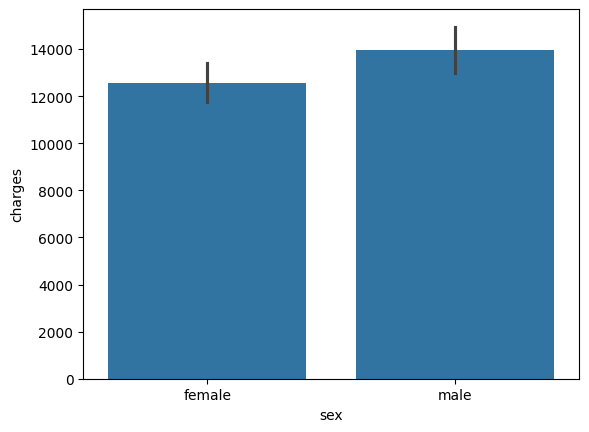

In [59]:
sns.barplot(data=df,x="sex",y="charges");

In [60]:
sex_codes = {"male":1,"female":0}
df["sex_codes"] = df.sex.map(sex_codes)
df.charges.corr(df.sex_codes)
df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [61]:
inputs, targets = df[["age","bmi","children","smoker_codes","sex_codes"]],df["charges"]

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)
print("Loss : " ,loss)

Loss :  6056.100708754546


One Hot encoding

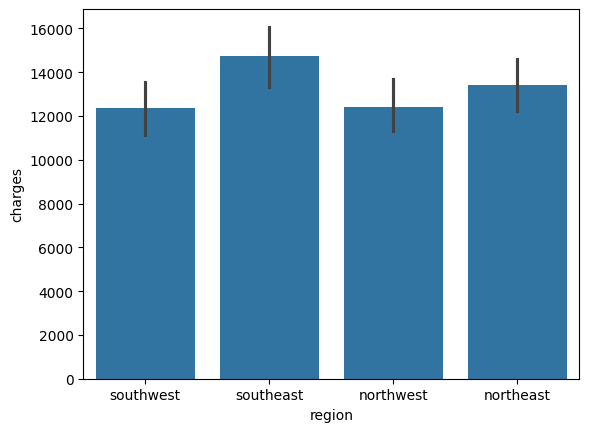

In [62]:
sns.barplot(data=df,x="region",y="charges");

In [63]:
ohe = OneHotEncoder()

ohe.fit(df[["region"]])
ohe.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [64]:
one_hot = ohe.transform(df[["region"]]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [65]:
df[["northeast","northwest","southeast","southwest"]] = one_hot
df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [66]:
inputs, targets = df[["age","bmi","children","smoker_codes","sex_codes","northeast","northwest","southeast","southwest"]],df["charges"]

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)
print("Loss : " ,loss)

Loss :  6041.6796511744515


In [ ]:
""""""""




""""""

non_smoker_df = df[df["smoker"] == "no"]
non_smoker_df

sex_codes = {"male":1,"female":0}
non_smoker_df["sex_codes"] = non_smoker_df.sex.map(sex_codes)
non_smoker_df.charges.corr(non_smoker_df.sex_codes)

one_hot = ohe.transform(non_smoker_df[["region"]]).toarray()
non_smoker_df[["northeast","northwest","southeast","southwest"]] = one_hot


inputs, targets = non_smoker_df[["age","bmi","children","smoker_codes","sex_codes","northeast","northwest","southeast","southwest"]],non_smoker_df["charges"]

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)
print("Loss : " ,loss)

Feature Scaling

In [ ]:
numeric_cols = ["age","bmi","children"]
scaler = StandardScaler()
scaler.fit(df[numeric_cols])

In [69]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [70]:
scaler.var_  #var = std ^ 2

array([197.25385199,  37.16008997,   1.45212664])

In [71]:
scaled_inputs = scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [72]:
cat_cols = ["smoker_codes","sex_codes","northeast","northwest","southeast","southwest"]
categorical_data = df[cat_cols].values

In [73]:
inputs = np.concatenate((scaled_inputs,categorical_data),axis=1)
targets = df.charges

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets,predictions)
print("Loss : " ,loss)

Loss :  6041.679651174452


In [78]:
weights_df = pd.DataFrame({
    "Feature":np.append(numeric_cols + cat_cols , 1),
    "Weight" : np.append(model.coef_ , model.intercept_)
})

weights_df.sort_values('Weight',ascending=False)

,Feature,Weight
3,smoker_codes,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_codes,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814
